In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from google.colab import files

In [2]:
metals = ['Aluminium', 'Copper', 'Nickel', 'Oil', 'Zinc']
def get_merged_df(metal):
  # Loading in the data
  commodity_df = pd.read_csv(f'{metal}_prices.csv')
  equities_df = pd.read_csv(f'{metal}_equities.csv')

  # Oil has daily prices so resample them to month-end
  if metal == 'Oil':
    commodity_df['Date'] = pd.to_datetime(commodity_df['Date'], dayfirst=True)
    commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()

  # Creating a copy of commodity file to manipulate
  commodity_monthly = commodity_df.copy()
  commodity_monthly['Date'] = pd.to_datetime(commodity_monthly['Date'], dayfirst=True)

  # Calculating the commodity return column
  commodity_monthly['CommodityReturn'] = np.log(commodity_monthly['Price']/commodity_monthly['Price'].shift(1))

  # Converting the Month Column to datetime
  commodity_monthly['Month'] = commodity_monthly['Date'].dt.to_period('M').dt.to_timestamp()

  # Creating a copy of the equity data
  equities_monthly = equities_df.copy()

  # Converting necessary columns to datetime and numeric
  equities_monthly['Date'] = pd.to_datetime(equities_monthly['Date'], dayfirst=True)
  equities_monthly['Month'] = equities_monthly['Date'].dt.to_period('M').dt.to_timestamp()
  equities_monthly['Return'] = pd.to_numeric(equities_monthly['Return'], errors='coerce')

  # Sort equities on date (to later group them by Month)
  equities_monthly = equities_monthly.sort_values('Date')
  equities_monthly = equities_monthly.drop_duplicates(subset=['PERMNO', 'Month'], keep='last')

  # Equal-weighted return (mean of returns)
  equal_weight_returns = equities_monthly.groupby('Month')['Return'].mean().reset_index()
  equal_weight_returns.rename(columns={'Return': 'EquityReturn_EQ'}, inplace=True)

  # Value-weighted return
  def vw_ret(group):
    weights = group['MktCap']
    returns = group['Return']
    if weights.sum() == 0:
      return np.nan
    return np.average(returns, weights=weights)

  value_weight_returns = equities_monthly.groupby('Month').apply(vw_ret).reset_index(name='EquityReturn_VW')

  # Merge both into one equity return table
  portfolio_returns = pd.merge(equal_weight_returns, value_weight_returns, on='Month', how='inner')

  # Merge with commodity returns
  merged = pd.merge(
      commodity_monthly[['Month', 'CommodityReturn']],
      portfolio_returns,
      on='Month',
      how='inner'
  )

  return merged

In [4]:
def load_term_spread(filepath=r"/content/T10Y2YM.xlsx"):
    df = pd.read_excel(filepath, engine='openpyxl')
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df['Month'] = df['observation_date'].dt.to_period('M').dt.to_timestamp()
    df['TermSpread'] = pd.to_numeric(df['T10Y2YM'], errors='coerce')
    df = df[['Month', 'TermSpread']].dropna()
    return df

def load_inflation(filepath='/content/CPIAUCSL.xlsx'):
    df = pd.read_excel(filepath, engine='openpyxl')  # Fix: correctly load Excel
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df['Month'] = df['observation_date'].dt.to_period('M').dt.to_timestamp()
    df = df[['Month', 'Inflation']].dropna()
    return df

def implement_t(metal):
    # Load data
    commodity_df = pd.read_csv(f'{metal}_prices.csv')
    equities_df = pd.read_csv(f'{metal}_equities.csv')

    # Format commodity data
    commodity_df['Date'] = pd.to_datetime(commodity_df['Date'], dayfirst=True)
    if metal == 'Oil':
        commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()

    commodity_df = commodity_df.sort_values('Date')
    commodity_df['Return'] = np.log(commodity_df['Price'] / commodity_df['Price'].shift(1))

    # Create shocks
    rolling_std = commodity_df['Return'].rolling(window=12).std()
    commodity_df['Dpos'] = (commodity_df['Return'] >= 2 * rolling_std).astype(int)
    commodity_df['Dneg'] = (commodity_df['Return'] <= -2 * rolling_std).astype(int)
    commodity_df['DnoShock'] = 1 - (commodity_df['Dpos'] + commodity_df['Dneg'])

    # Lag values for t+1 equity prediction
    commodity_df[['Return', 'Dpos', 'Dneg', 'DnoShock']] = commodity_df[['Return', 'Dpos', 'Dneg', 'DnoShock']].shift(1)
    commodity_df['Month'] = commodity_df['Date'].dt.to_period('M').dt.to_timestamp()

    # Format equity data
    equities_df['Date'] = pd.to_datetime(equities_df['Date'], dayfirst=True)
    equities_df['Month'] = equities_df['Date'].dt.to_period('M').dt.to_timestamp()
    equities_df['Return'] = pd.to_numeric(equities_df['Return'], errors='coerce')

    # Use last observation per stock per month
    equities_df = equities_df.sort_values('Date')
    equities_df = equities_df.drop_duplicates(subset=['PERMNO', 'Month'], keep='last')

    # Equal-weighted return for the metal producers
    portfolio_returns = equities_df.groupby('Month')['Return'].mean().reset_index()
    portfolio_returns.rename(columns={'Return': 'EquityReturn'}, inplace=True)

    # Merge returns
    merged_shock = pd.merge(
        commodity_df[['Month', 'Return', 'Dpos', 'Dneg', 'DnoShock']],
        portfolio_returns,
        on='Month',
        how='inner'
    )
    # Load inflation data
    inflation_df = load_inflation()

    # Merge in inflation
    merged_shock = pd.merge(
        merged_shock,
        inflation_df,
        on='Month',
        how='left'
        )


    merged_shock.rename(columns={'Return': 'MetalReturn'}, inplace=True)

    return merged_shock

def run_regression_includingShocks_predictive(df, metal):
    # Interaction terms
    df['metal_Dpos'] = df['MetalReturn'] * df['Dpos']
    df['metal_Dneg'] = df['MetalReturn'] * df['Dneg']
    df['metal_DnoShock'] = df['MetalReturn'] * df['DnoShock']

    # Drop any rows with missing inflation data
    df = df.dropna(subset=['Inflation'])

    X = df[['metal_Dpos', 'metal_Dneg', 'metal_DnoShock', 'Inflation']]
    X = sm.add_constant(X)
    y = df['EquityReturn']

    model = sm.OLS(y, X).fit()
    print(f"\nRegression results predictive power for {metal}:\n")
    print(model.summary())
    return model


results = {}
df = pd.DataFrame()

for metal in metals:
    df = implement_t(metal)
    df.dropna(inplace=True)
    model = run_regression_includingShocks_predictive(df, metal)
    results[metal] = model


Regression results predictive power for Aluminium:

                            OLS Regression Results                            
Dep. Variable:           EquityReturn   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.522
Date:                Tue, 15 Apr 2025   Prob (F-statistic):              0.195
Time:                        15:13:13   Log-Likelihood:                 359.15
No. Observations:                 402   AIC:                            -708.3
Df Residuals:                     397   BIC:                            -688.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

<ipython-input-4-6881db52b2d7>:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()



Regression results predictive power for Oil:

                            OLS Regression Results                            
Dep. Variable:           EquityReturn   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     5.568
Date:                Tue, 15 Apr 2025   Prob (F-statistic):           0.000226
Time:                        15:13:13   Log-Likelihood:                 421.06
No. Observations:                 418   AIC:                            -832.1
Df Residuals:                     413   BIC:                            -811.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [5]:
def implement_same(metal):
    # Load data
    commodity_df = pd.read_csv(f'{metal}_prices.csv')
    equities_df = pd.read_csv(f'{metal}_equities.csv')

    # Format commodity data
    commodity_df['Date'] = pd.to_datetime(commodity_df['Date'], dayfirst=True)
    if metal == 'Oil':
        commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()

    commodity_df = commodity_df.sort_values('Date')
    commodity_df['Return'] = np.log(commodity_df['Price'] / commodity_df['Price'].shift(1))

    # Create shocks
    rolling_std = commodity_df['Return'].rolling(window=12).std()
    commodity_df['Dpos'] = (commodity_df['Return'] >= 2 * rolling_std).astype(int)
    commodity_df['Dneg'] = (commodity_df['Return'] <= -2 * rolling_std).astype(int)
    commodity_df['DnoShock'] = 1 - (commodity_df['Dpos'] + commodity_df['Dneg'])


    # Values for t equity prediction
    commodity_df[['Return', 'Dpos', 'Dneg', 'DnoShock']] = commodity_df[['Return', 'Dpos', 'Dneg', 'DnoShock']].shift(1)
    commodity_df['Month'] = commodity_df['Date'].dt.to_period('M').dt.to_timestamp()

    # Format equity data
    equities_df['Date'] = pd.to_datetime(equities_df['Date'], dayfirst=True)
    equities_df['Month'] = equities_df['Date'].dt.to_period('M').dt.to_timestamp()
    equities_df['Return'] = pd.to_numeric(equities_df['Return'], errors='coerce')

    # Use last observation per stock per month
    equities_df = equities_df.sort_values('Date')
    equities_df = equities_df.drop_duplicates(subset=['PERMNO', 'Month'], keep='last')

    # Equal-weighted return for the metal producers
    portfolio_returns = equities_df.groupby('Month')['Return'].mean().reset_index()
    portfolio_returns.rename(columns={'Return': 'EquityReturn'}, inplace=True)

    # Merge returns
    merged_cross = pd.merge(
        commodity_df[['Month', 'Return', 'Dpos', 'Dneg', 'DnoShock']],
        portfolio_returns,
        on='Month',
        how='inner'
    )
    # Load inflation data
    inflation_df = load_inflation()

    # Merge in inflation
    merged_cross = pd.merge(
        merged_cross,
        inflation_df,
        on='Month',
        how='left'
        )


    merged_cross.rename(columns={'Return': 'MetalReturn'}, inplace=True)

    return merged_cross

def run_regression_includingShocks_cross_sectional(df, metal):
    # Interaction terms
    df['metal_Dpos'] = df['MetalReturn'] * df['Dpos']
    df['metal_Dneg'] = df['MetalReturn'] * df['Dneg']
    df['metal_DnoShock'] = df['MetalReturn'] * df['DnoShock']

    # Drop any rows with missing inflation data
    df = df.dropna(subset=['Inflation'])

    X = df[['metal_Dpos', 'metal_Dneg', 'metal_DnoShock', 'Inflation']]
    X = sm.add_constant(X)
    y = df['EquityReturn']

    model = sm.OLS(y, X).fit()
    print(f"\nRegression results cross sectional power for {metal}:\n")
    print(model.summary())
    return model

results = {}

for metal in metals:
    df = implement_same(metal)
    df.dropna(inplace=True)
    model = run_regression_includingShocks_cross_sectional(df, metal)
    results[metal] = model


Regression results cross sectional power for Aluminium:

                            OLS Regression Results                            
Dep. Variable:           EquityReturn   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.522
Date:                Tue, 15 Apr 2025   Prob (F-statistic):              0.195
Time:                        15:13:21   Log-Likelihood:                 359.15
No. Observations:                 402   AIC:                            -708.3
Df Residuals:                     397   BIC:                            -688.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

<ipython-input-5-bd6810b83742>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()



Regression results cross sectional power for Oil:

                            OLS Regression Results                            
Dep. Variable:           EquityReturn   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     5.568
Date:                Tue, 15 Apr 2025   Prob (F-statistic):           0.000226
Time:                        15:13:22   Log-Likelihood:                 421.06
No. Observations:                 418   AIC:                            -832.1
Df Residuals:                     413   BIC:                            -811.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [12]:
def preprocess_metal_shock_strategy(df):
    df = df.copy()

    # Create a signal: 1 if positive shock, -1 if negative, 0 otherwise
    df['ShockSignal'] = np.where(df['Dpos'] == 1, 1,
                                 np.where(df['Dneg'] == 1, -1, 0))
    return df[['Month', 'ShockSignal', 'EquityReturn']]

# Build dictionary of metal-specific data with shock signals
metal_data_dict = {}
for metal in metals:
    df = implement_t(metal)
    df.dropna(subset=['Dpos', 'Dneg', 'EquityReturn'], inplace=True)
    metal_data_dict[metal] = preprocess_metal_shock_strategy(df)

# Load S&P500 returns (used as baseline when no commodity shock occurs)
def load_sp500(filepath="/content/S&P_prices.csv"):
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()
    df = df[['Month', 'Return']].dropna()
    df.rename(columns={'Return': 'BaselineReturn'}, inplace=True)
    return df

# Loading in the S&P500 data
sp500_df = load_sp500('S&P_prices.csv')

def composite_long_short_strategy(metal_data_dict, baseline_df):
    # Get all unique months from both baseline and metal datasets
    all_months = sorted(set(baseline_df['Month']).union(*(df['Month'] for df in metal_data_dict.values())))
    composite_results = []        # Stores results with transaction costs
    no_cost_results = []          # Stores results without transaction costs
    monthly_turnover = []         # Tracks turnover events (entries + exits) per month


    # Track per-metal stats: number of long/short positions and total contribution
    metal_stats = {
        metal: {'Long': 0, 'Short': 0, 'Contribution': 0.0} for metal in metal_data_dict.keys()
    }

    # Tracking long/short returns
    long_returns = []
    short_returns = []

    previous_positions = set()    # Tracks metals held in the previous month
    cost_long = 0.0005            # Buying costs
    cost_short = 0.001            # Selling costs

    for month in all_months:
        monthly_returns = []      # Raw monthly returns from signals
        total_costs = 0.0         # Transaction costs for the current month
        current_positions = set() # Set of metals traded this month

        for metal, df in metal_data_dict.items():
            # Creates a dataframe for a specific month (in the month column so mm/yyyy)
            row = df[df['Month'] == month]
            if not row.empty:
                signal = row['ShockSignal'].iloc[0]
                equity_ret = row['EquityReturn'].iloc[0]

                if signal != 0:
                    # Track trade direction
                    if signal == 1:
                        metal_stats[metal]['Long'] += 1
                        total_costs += cost_long
                    elif signal == -1:
                        metal_stats[metal]['Short'] += 1
                        total_costs += cost_short

                    current_positions.add(metal)

                    contribution = signal * equity_ret
                    monthly_returns.append(contribution)
                    metal_stats[metal]['Contribution'] += contribution

                    if signal == 1:
                      long_returns.append(contribution)
                    elif signal == -1:
                      short_returns.append(contribution)

        # Determine return for the current month
        if not monthly_returns:
            # Fallback to S&P if no shocks
            baseline_row = baseline_df[baseline_df['Month'] == month]
            composite_return = baseline_row['BaselineReturn'].iloc[0] if not baseline_row.empty else 0
            no_cost_return = composite_return

            if previous_positions:
                # Exiting signal positions to re-enter S&P
                total_costs += len(previous_positions) * cost_short
                total_costs += cost_long

        else:
            # Signal-based return
            avg_return = np.mean(monthly_returns)
            no_cost_return = avg_return  # Without transaction cost

            if not previous_positions:
                # Switching from S&P to metal signals
                total_costs += cost_short  # Exit S&P
                total_costs += len(current_positions) * cost_long  # Enter signal positions

            composite_return = avg_return - total_costs

        # Treat 'S&P' as a placeholder position when no signals are active
        if not current_positions:
          current_positions = {'S&P'}
        if not previous_positions:
          previous_positions = {'S&P'}

        # Calculate turnover: positions entered or exited this month
        entries = current_positions - previous_positions
        exits = previous_positions - current_positions
        turnover_events = len(entries) + len(exits)
        monthly_turnover.append(turnover_events)

        # Save positions for next month comparison
        previous_positions = current_positions.copy()

        # Store results
        composite_results.append({
            'Month': month,
            'CompositeReturn': composite_return,
            'TransactionCost': total_costs
        })

        no_cost_results.append({
            'Month': month,
            'CompositeReturn': no_cost_return  # No transaction cost version
        })

    # Convert to DataFrames and compute cumulative returns
    composite_df = pd.DataFrame(composite_results)
    composite_df.sort_values('Month', inplace=True)
    composite_df['CumulativeReturn'] = (1 + composite_df['CompositeReturn']).cumprod()

    no_cost_df = pd.DataFrame(no_cost_results)
    no_cost_df.sort_values('Month', inplace=True)
    no_cost_df['CumulativeReturn'] = (1 + no_cost_df['CompositeReturn']).cumprod()

    # Turnover metrics (hypothesizing more trades during crises)
    total_turnover = sum(monthly_turnover)
    average_monthly_turnover = total_turnover / len(monthly_turnover)

    # Long-short contribution stats
    long_total = sum(long_returns)
    short_total = sum(short_returns)
    net_total = composite_df['CompositeReturn'].sum()

    long_share = 100 * long_total / net_total if net_total != 0 else 0
    short_share = 100 * short_total / net_total if net_total != 0 else 0

    print(f"Long-side contributed: {long_total:.4f} ({long_share:.2f}%)")
    print(f"Short-side contributed: {short_total:.4f} ({short_share:.2f}%)")
    print(f"Total net return: {net_total:.4f}")

    return composite_df, no_cost_df, metal_stats, monthly_turnover, total_turnover, average_monthly_turnover



<ipython-input-4-6881db52b2d7>:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()
<ipython-input-12-0956fe0cde36>:19: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


Long-side contributed: 0.7190 (14.28%)
Short-side contributed: 1.9544 (38.82%)
Total net return: 5.0346
0.00909290353651991
total_turnover:  328
average_monthly_turnover:  0.780952380952381


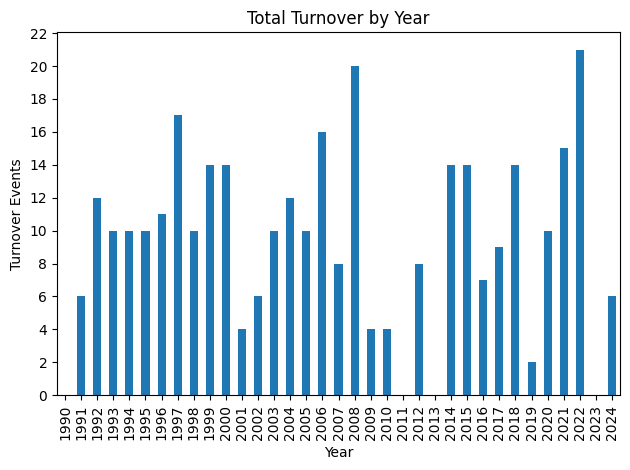

Shock strategy activity summary:

Aluminium: Long = 18, Short = 8, Total Contribution = 0.51
Copper: Long = 15, Short = 11, Total Contribution = 0.56
Nickel: Long = 11, Short = 9, Total Contribution = -0.01
Oil: Long = 6, Short = 14, Total Contribution = 0.58
Zinc: Long = 16, Short = 9, Total Contribution = 1.02


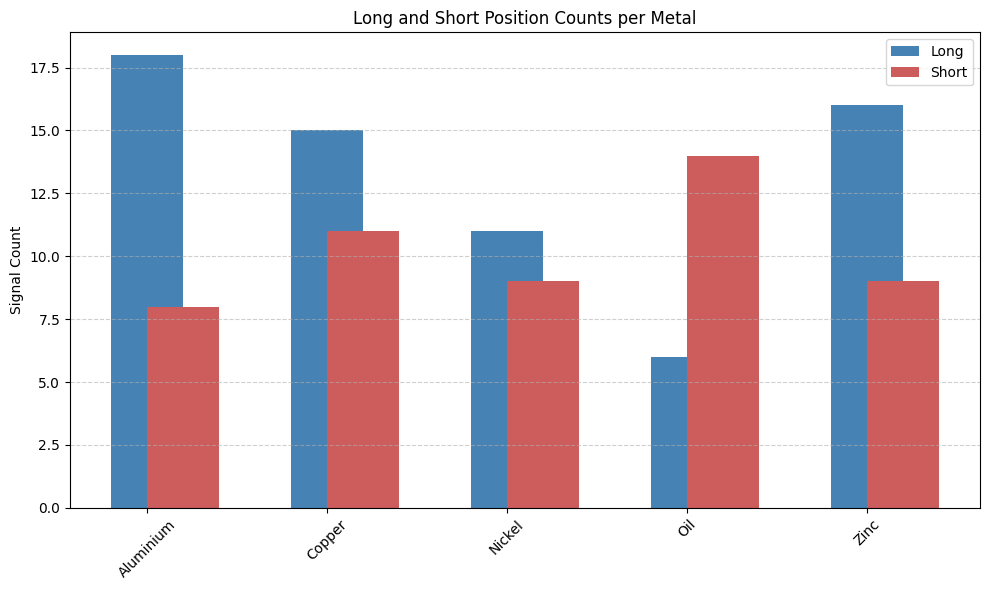

In [14]:
composite_df, no_cost_df, metal_stats, monthly_turnover, total_turnover, average_monthly_turnover = composite_long_short_strategy(metal_data_dict, sp500_df)
cumulative_cost = composite_df['TransactionCost'].sum()
final_return = composite_df['CumulativeReturn'].iloc[-1]
final_share = cumulative_cost/final_return
print(final_share)
print("total_turnover: ", total_turnover)
print("average_monthly_turnover: ", average_monthly_turnover)

# Getting turnover amount each year
composite_df['Year'] = composite_df['Month'].dt.year
composite_df['Turnover'] = monthly_turnover

turnover_by_year = composite_df.groupby('Year')['Turnover'].sum()

# Plotting turnover graph
turnover_by_year.plot(kind='bar', title='Total Turnover by Year', ylabel='Turnover Events', xlabel='Year')
max_turnover = turnover_by_year.max()
plt.yticks(np.arange(0, max_turnover + 2, 2))
plt.tight_layout()
plt.show()

print("Shock strategy activity summary:\n")
for metal, stats in metal_stats.items():
    print(f"{metal}: Long = {stats['Long']}, Short = {stats['Short']}, Total Contribution = {stats['Contribution']:.2f}")


# Bar chart for Long/Short counts
metal_names = list(metal_stats.keys())
long_counts = [metal_stats[m]['Long'] for m in metal_names]
short_counts = [metal_stats[m]['Short'] for m in metal_names]

x = range(len(metal_names))

plt.figure(figsize=(10, 6))
plt.bar(x, long_counts, width=0.4, label='Long', align='center', color='steelblue')
plt.bar(x, short_counts, width=0.4, label='Short', align='edge', color='indianred')
plt.xticks(x, metal_names, rotation=45)
plt.ylabel('Signal Count')
plt.title('Long and Short Position Counts per Metal')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Aluminium: 0.80% of total cumulative return
Copper: 0.88% of total cumulative return
Nickel: -0.01% of total cumulative return
Oil: 0.91% of total cumulative return
Zinc: 1.59% of total cumulative return


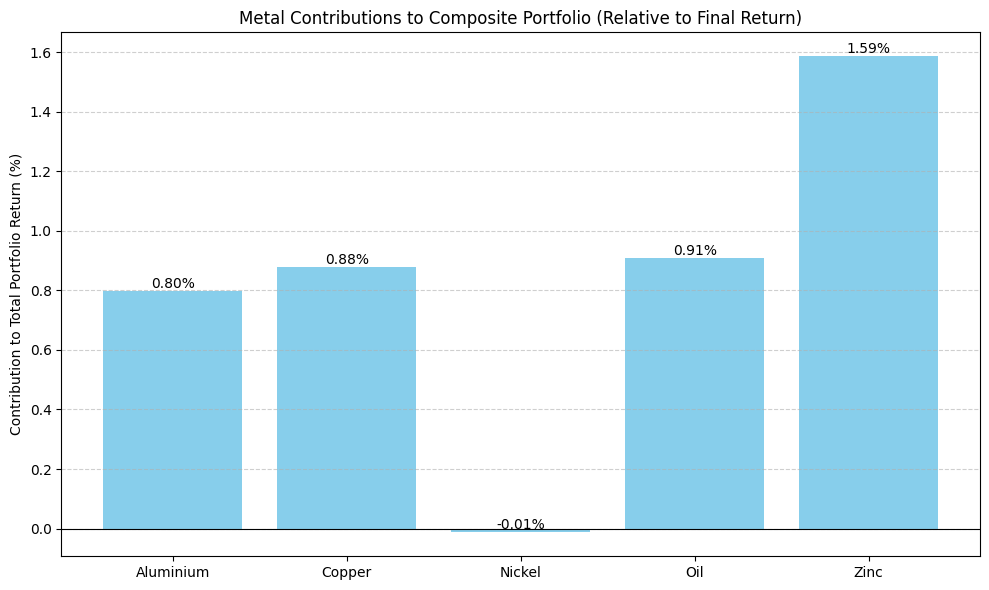

In [10]:
final_portfolio_value = composite_df['CumulativeReturn'].iloc[-1]

total_contributions = {
    metal: stats['Contribution']
    for metal, stats in metal_stats.items()
}

# Calculate percentage contribution relative to full portfolio
relative_to_total = {
    metal: (value / final_portfolio_value) * 100
    for metal, value in total_contributions.items()
}

for metal, pct in relative_to_total.items():
    print(f"{metal}: {pct:.2f}% of total cumulative return")

# Calculate percentage contribution of each metal
relative_contributions = {
    metal: (value / final_portfolio_value) * 100
    for metal, value in total_contributions.items()
}

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(relative_contributions.keys(), relative_contributions.values(), color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Contribution to Total Portfolio Return (%)")
plt.title("Metal Contributions to Composite Portfolio (Relative to Final Return)")

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}%", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

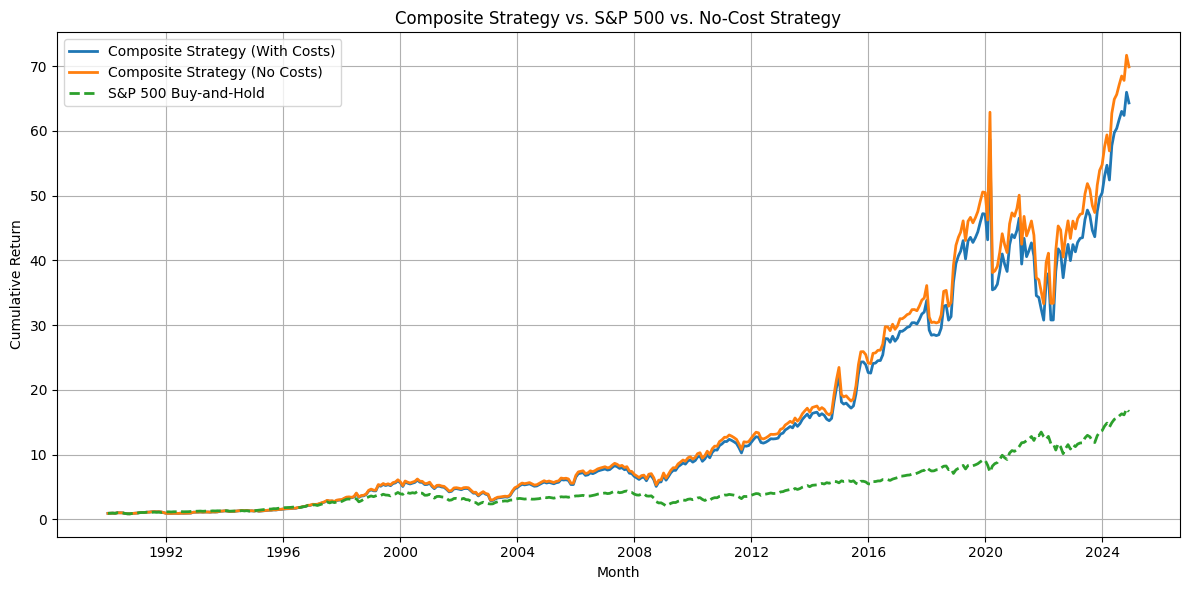

In [11]:
plot_df = composite_df.copy()
plot_df_no_cost = no_cost_df.copy()

# Merge with S&P 500 monthly returns
plot_df = pd.merge(plot_df, sp500_df, on='Month', how='left')
plot_df_no_cost = pd.merge(plot_df_no_cost, sp500_df, on='Month', how='left')

# Calculates cumulative return for S&P 500
plot_df['CumulativeSP500'] = (1 + plot_df['BaselineReturn'].fillna(0)).cumprod()
plot_df_no_cost['CumulativeSP500'] = (1 + plot_df_no_cost['BaselineReturn'].fillna(0)).cumprod()

# Plotting all three cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Month'], plot_df['CumulativeReturn'], label='Composite Strategy (With Costs)', linewidth=2)
plt.plot(plot_df_no_cost['Month'], plot_df_no_cost['CumulativeReturn'], label='Composite Strategy (No Costs)', linewidth=2)
plt.plot(plot_df['Month'], plot_df['CumulativeSP500'], label='S&P 500 Buy-and-Hold', linestyle='--', linewidth=2)

plt.xlabel('Month')
plt.ylabel('Cumulative Return')
plt.title('Composite Strategy vs. S&P 500 vs. No-Cost Strategy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
def calculate_performance_metrics(df, return_col='CompositeReturn', label='Strategy'):
    df = df.copy()
    df = df.dropna(subset=[return_col])

    # CAGR
    n_months = len(df)
    final_value = (1 + df[return_col]).cumprod().iloc[-1]
    cagr = final_value ** (12 / n_months) - 1

    # Sharpe Ratio
    mean_return = df[return_col].mean() * 12
    std_dev = df[return_col].std() * (12 ** 0.5)
    sharpe_ratio = mean_return / std_dev if std_dev != 0 else float('nan')

    return {
        'Label': label,
        'CAGR': cagr,
        'Annualized Return': mean_return,
        'Annualized Volatility': std_dev,
        'Sharpe Ratio': sharpe_ratio
    }

strategy_stats_costs = calculate_performance_metrics(composite_df, 'CompositeReturn', label='Composite Strategy (costs inclusive)')
sp500_stats = calculate_performance_metrics(sp500_df, 'BaselineReturn', label='S&P 500')
strategy_nocosts = calculate_performance_metrics(no_cost_df,'CompositeReturn', label= 'Composite Startegy (costs exclusive)' )

performance_df = pd.DataFrame([strategy_stats_costs, strategy_nocosts, sp500_stats])
print(performance_df)

                                  Label      CAGR  Annualized Return  \
0  Composite Strategy (costs inclusive)  0.126342           0.143844   
1  Composite Startegy (costs exclusive)  0.129018           0.146244   
2                               S&P 500  0.083658           0.091679   

   Annualized Volatility  Sharpe Ratio  
0               0.218340      0.658810  
1               0.218504      0.669299  
2               0.148144      0.618850  


In [16]:
# Calculating summary statisitcs
# Function to calculate all necessary return statisitcs
def compute_combined_stats(ret_series, freq=12):
    mean = ret_series.mean()
    std = ret_series.std()
    min_val = ret_series.min()
    max_val = ret_series.max()
    ann_return = mean * freq
    ann_vol = std * (freq ** 0.5)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    # Making the function return a dictionary
    return {
        'Mean Monthly Return': mean,
        'Monthly Std Dev': std,
        'Min Return': min_val,
        'Max Return': max_val,
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe
    }

# Loop through all metals and compute stats
combined_stats = {}

for metal, df in metal_data_dict.items():
    stats = compute_combined_stats(df['EquityReturn'])
    combined_stats[metal] = stats

# Convert to DataFrame
combined_stats_df = pd.DataFrame(combined_stats).T
combined_stats_df = combined_stats_df.round(4)  # Round for presentation

# Displaying the summary table
print("Combined Return Statistics per Commodity:")
print(combined_stats_df)


Combined Return Statistics per Commodity:
           Mean Monthly Return  Monthly Std Dev  Min Return  Max Return  \
Aluminium               0.0047           0.0999     -0.3600      0.3300   
Copper                  0.0156           0.1043     -0.3161      0.3513   
Nickel                  0.0100           0.1386     -0.4119      0.5925   
Oil                     0.0112           0.0907     -0.3919      0.5231   
Zinc                    0.0116           0.1597     -0.5638      1.7069   

           Annualized Return  Annualized Volatility  Sharpe Ratio  
Aluminium             0.0564                 0.3461        0.1629  
Copper                0.1873                 0.3614        0.5184  
Nickel                0.1198                 0.4800        0.2497  
Oil                   0.1347                 0.3143        0.4285  
Zinc                  0.1388                 0.5533        0.2509  


In [17]:
# Combining all equity returns from metal datasets
all_equity_returns = []

for metal, df in metal_data_dict.items():
    df = df[['Month', 'EquityReturn']].copy()
    df['Metal'] = metal
    all_equity_returns.append(df)

equity_df = pd.concat(all_equity_returns, ignore_index=True)

# Drops missing returns just in case
equity_df.dropna(subset=['EquityReturn'], inplace=True)

# Merge all returns with S&P 500
sp500_df_clean = sp500_df[['Month', 'BaselineReturn']].dropna()
sp500_df_clean.rename(columns={'BaselineReturn': 'SP500Return'}, inplace=True)

# Descriptive stats for equity and SP500 returns
summary_stats = {
    'Equal- weighted Equity Returns': equity_df['EquityReturn'].describe(),
    'S&P 500 Returns': sp500_df_clean['SP500Return'].describe()
}

# Create a summary DataFrame
summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.rename_axis("Statistic").round(4)

print("Combined Return Descriptive Statistics:")
print(summary_df)

Combined Return Descriptive Statistics:
           Equal- weighted Equity Returns  S&P 500 Returns
Statistic                                                 
count                           1968.0000         420.0000
mean                               0.0106           0.0076
std                                0.1191           0.0428
min                               -0.5638          -0.1694
25%                               -0.0570          -0.0177
50%                                0.0045           0.0117
75%                                0.0664           0.0348
max                                1.7069           0.1268


In [18]:
# Initialsing firm summary data
firm_summary = []

def summary(metal):
  df = pd.read_csv(f'{metal}_equities.csv')

  num_firms = df['PERMNO'].nunique()
  df['SecurityBegDt'] = pd.to_datetime(df['SecurityBegDt'], dayfirst=True)
  df['SecurityEndDt'] = pd.to_datetime(df['SecurityEndDt'], dayfirst=True, errors='coerce')

  # Calculating listing length in years
  df['ListingLength'] = (df['SecurityEndDt'] - df['SecurityBegDt']).dt.days / 365.25

  avg_mktcap = df.groupby('PERMNO')['MktCap'].mean().mean()  # Listing per firm, not per row
  avg_mktcap = (avg_mktcap/1e6).round(2)
  avg_listing = df.groupby('PERMNO')['ListingLength'].mean().mean()

  firm_summary.append({'Metal': metal,
                       'Number of Firms': num_firms,
                       'Average Market Cap (in millions of $)': avg_mktcap,
                       'Average Listing Length': avg_listing})

for metal in metals:
    summary(metal)

firm_summary_df = pd.DataFrame(firm_summary)
firm_summary_df.set_index('Metal', inplace=True)

print("Firm-Level Descriptive Statistics by Metal:")
print(firm_summary_df)

Firm-Level Descriptive Statistics by Metal:
           Number of Firms  Average Market Cap (in millions of $)  \
Metal                                                               
Aluminium               10                                   4.28   
Copper                  30                                   3.02   
Nickel                  21                                   0.64   
Oil                    510                                   3.38   
Zinc                    11                                   2.86   

           Average Listing Length  
Metal                              
Aluminium               25.475702  
Copper                  17.717363  
Nickel                  18.975001  
Oil                     17.618102  
Zinc                    28.150333  


<ipython-input-19-564790bbf8f9>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()


Correlation Matrix of Commodity Returns:
           Aluminium    Copper    Nickel       Oil      Zinc
Aluminium   1.000000  0.645168  0.523207  0.293900  0.552950
Copper      0.645168  1.000000  0.546674  0.309141  0.630474
Nickel      0.523207  0.546674  1.000000  0.207619  0.519862
Oil         0.293900  0.309141  0.207619  1.000000  0.199436
Zinc        0.552950  0.630474  0.519862  0.199436  1.000000


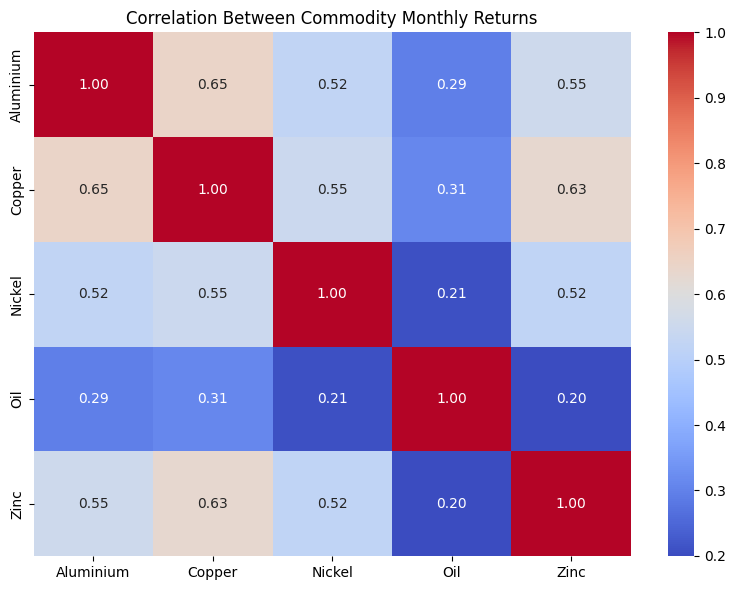

In [19]:
# Initialsing a common commodity return array (stored as DataFrames)
commodity_dfs = []

for metal in metals:
  commodity_df = pd.read_csv(f'{metal}_prices.csv')
  # Oil have daily prices so resample them to month-end
  if metal == 'Oil':
    commodity_df['Date'] = pd.to_datetime(commodity_df['Date'], dayfirst=True)
    commodity_df = commodity_df.set_index('Date').resample('M').last().reset_index()

  # Creating a copy of commodity file to manipulate
  commodity_monthly = commodity_df.copy()
  commodity_monthly['Date'] = pd.to_datetime(commodity_monthly['Date'], dayfirst=True)

  # Calculating the commodity return column
  commodity_monthly['CommodityReturn'] = np.log(commodity_monthly['Price']/commodity_monthly['Price'].shift(1))

  # Converting the Month Column to datetime
  commodity_monthly['Month'] = commodity_monthly['Date'].dt.to_period('M').dt.to_timestamp()

  # Keep only necessary columns
  clean_df = commodity_monthly[['Month', 'CommodityReturn']].copy()
  clean_df.rename(columns={'CommodityReturn': metal}, inplace=True)

  commodity_dfs.append(clean_df)

merged_returns = commodity_dfs[0][['Month', metals[0]]].copy()

for i in range(1, len(commodity_dfs)):
    df = commodity_dfs[i][['Month', metals[i]]].copy()  # Only Month + 1 metal column
    merged_returns = pd.merge(merged_returns, df, on='Month', how='inner')

# Drops rows with missing values
merged_returns.dropna(inplace=True)

# Calculates correlation matrix
correlation_matrix = merged_returns.drop(columns='Month').corr()

print("Correlation Matrix of Commodity Returns:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Commodity Monthly Returns")
plt.tight_layout()
plt.show()

In [20]:
# Determining alpha (with transaction costs)
# Merging returns
merged = composite_df[['Month', 'CompositeReturn']].merge(
    sp500_df[['Month', 'BaselineReturn']], on='Month', how='inner'
)

# Defining variables
y = merged['CompositeReturn']
x = merged['BaselineReturn']
x = sm.add_constant(x)  # Adds intercept term

# Runs regression
model = sm.OLS(y, x).fit()

# Extracts alpha (intercept) and its t-stat
alpha = model.params['const']
alpha_tstat = model.tvalues['const']

print("Strategy WITH Transaction Costs")
print(f"Alpha: {alpha:.4f} per month")
print(f"Annualized Alpha: {((1 + alpha)**12 - 1):.4f}")
print(f"T-stat: {alpha_tstat:.2f}")

# Determining alpha without transaction costs
# Merging data
merged_nocost = no_cost_df[['Month', 'CompositeReturn']].merge(
    sp500_df[['Month', 'BaselineReturn']], on='Month', how='inner'
)

# Defining variables
y_nc = merged_nocost['CompositeReturn']
x_nc = merged_nocost['BaselineReturn']
x_nc = sm.add_constant(x_nc)

# Running regression
model_nc = sm.OLS(y_nc, x_nc).fit()
alpha_nc = model_nc.params['const']
alpha_nc_tstat = model_nc.tvalues['const']

print("Strategy WITHOUT Transaction Costs")
print(f"Alpha: {alpha_nc:.4f} per month")
print(f"Annualized Alpha: {((1 + alpha_nc)**12 - 1):.4f}")
print(f"T-stat: {alpha_nc_tstat:.2f}")


Strategy WITH Transaction Costs
Alpha: 0.0076 per month
Annualized Alpha: 0.0953
T-stat: 2.64
Strategy WITHOUT Transaction Costs
Alpha: 0.0078 per month
Annualized Alpha: 0.0980
T-stat: 2.71
